In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [5]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]

In [6]:
model_VoxelMorph = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
model_VoxelMorph.to(device)
optimizer = optim.Adam(model_VoxelMorph.parameters(), lr=1e-4)
model_VoxelMorph.load_state_dict(torch.load('a2.pth', map_location=device))

# model_VoxelMorph_CL = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
# model_VoxelMorph_CL.to(device)
# optimizer = optim.Adam(model_VoxelMorph_CL.parameters(), lr=1e-4)
# model_VoxelMorph_CL.load_state_dict(torch.load('model_VXM_3D_MInoBed_A50_B001_fn.pth', map_location=device))

# model_VoxelMorph_WE = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
# model_VoxelMorph_WE.to(device)
# optimizer = optim.Adam(model_VoxelMorph_WE.parameters(), lr=1e-4)
# model_VoxelMorph_WE.load_state_dict(torch.load('model_VXM_3D_MInoBed_A100_B001_fn.pth', map_location=device))

# model_VoxelMorph_CL_WE = vxm.networks.VxmDense1((64, 128, 128), nb_features, int_steps=0)
# model_VoxelMorph_CL_WE.to(device)
# optimizer = optim.Adam(model_VoxelMorph_CL_WE.parameters(), lr=1e-4)
# model_VoxelMorph_CL_WE.load_state_dict(torch.load('model_VXM_3D_MInoBed_A200_B001_fn.pth', map_location=device))

5
6
7
6
7
6
7
6
7
6
7
64
128
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
8
9
64
10
11
11
11
[32, 64, 64]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


<All keys matched successfully>

🔍 総ペア数: 101
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])


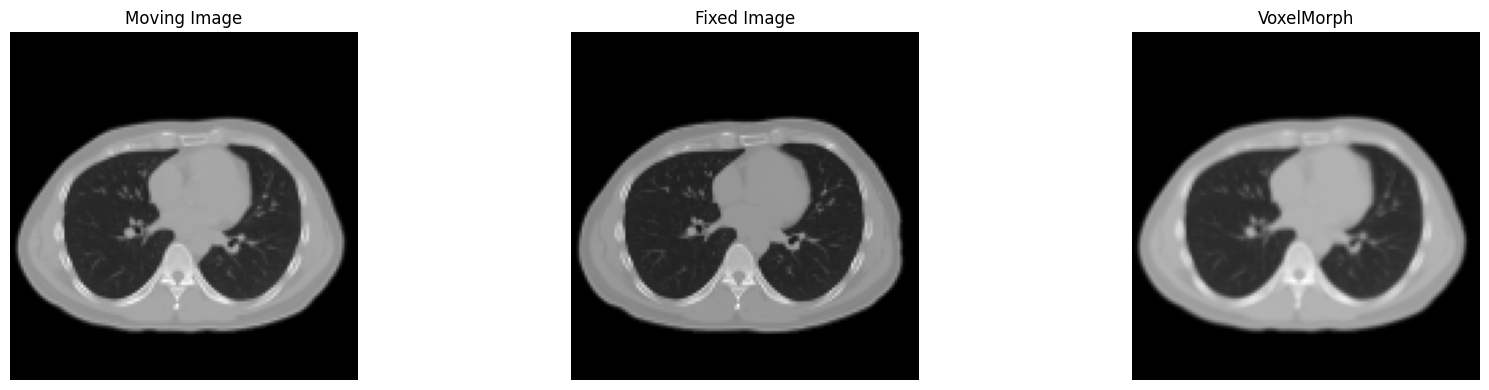


=== 📂 ペア: pair1 の評価結果 (slices 0..63) ===
| モデル名   |   Dice |   Jaccard |   SSIM |   FSIM |     RMSE |    NCC |
|------------|--------|-----------|--------|--------|----------|--------|
| VoxelMorph | 0.9219 |    0.8552 | 0.9495 | 0.8590 | 409.2208 | 0.9336 |
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])


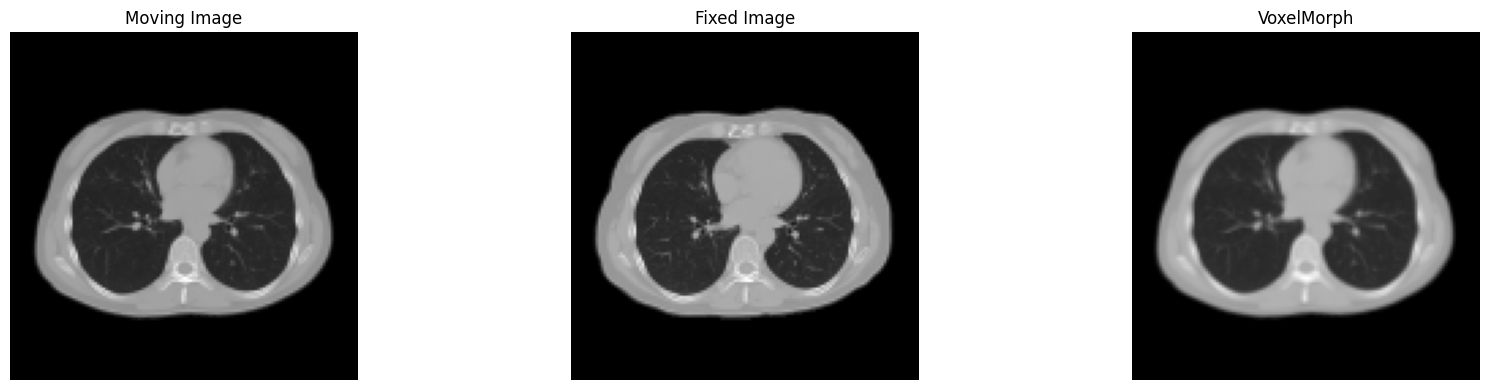


=== 📂 ペア: pair10 の評価結果 (slices 0..63) ===
| モデル名   |   Dice |   Jaccard |   SSIM |   FSIM |     RMSE |    NCC |
|------------|--------|-----------|--------|--------|----------|--------|
| VoxelMorph | 0.9367 |    0.8810 | 0.9522 | 0.8191 | 322.0983 | 0.9542 |
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])


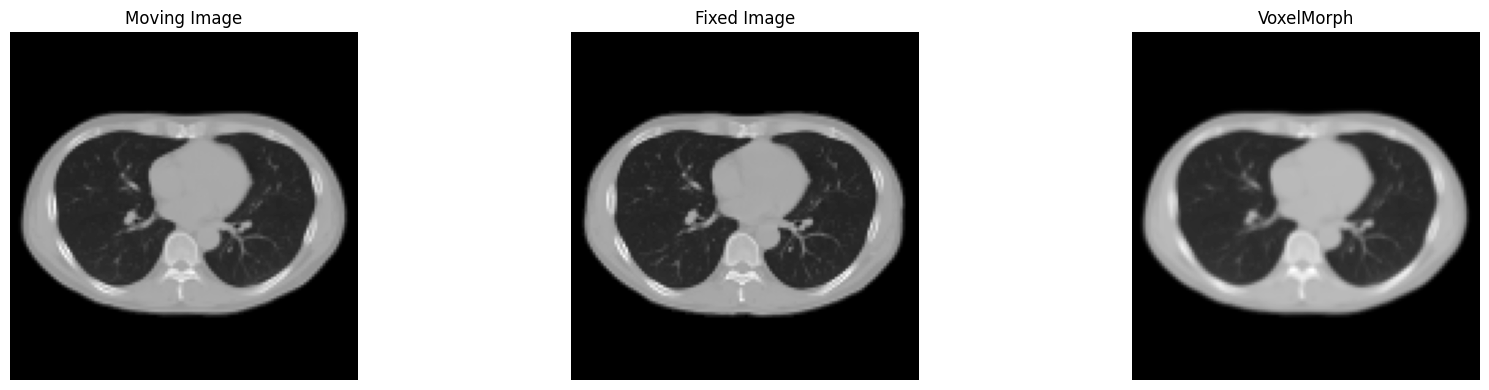


=== 📂 ペア: pair100 の評価結果 (slices 0..63) ===
| モデル名   |   Dice |   Jaccard |   SSIM |   FSIM |     RMSE |    NCC |
|------------|--------|-----------|--------|--------|----------|--------|
| VoxelMorph | 0.9269 |    0.8637 | 0.9652 | 0.8579 | 284.9982 | 0.9654 |
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])


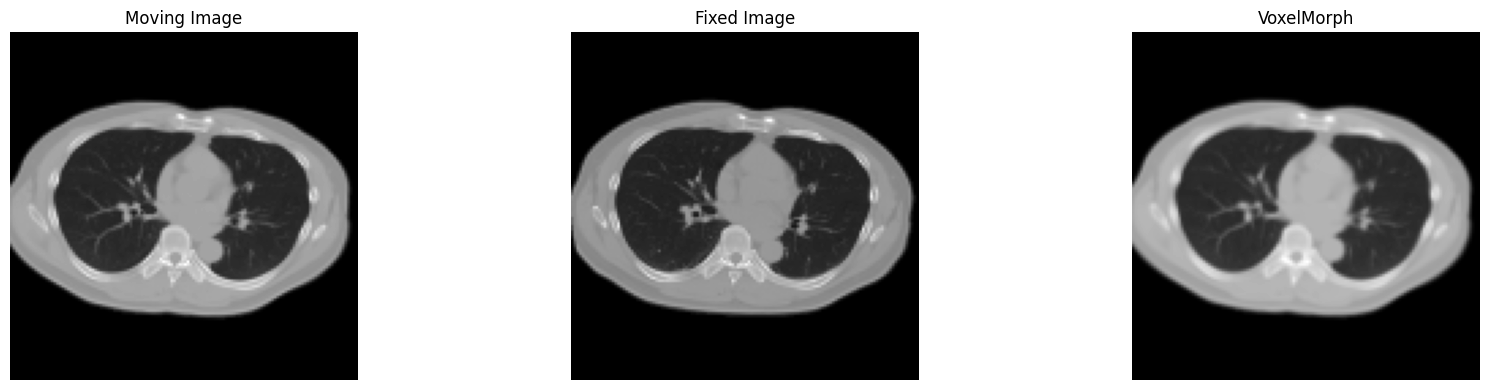


=== 📂 ペア: pair101 の評価結果 (slices 0..63) ===
| モデル名   |   Dice |   Jaccard |   SSIM |   FSIM |     RMSE |    NCC |
|------------|--------|-----------|--------|--------|----------|--------|
| VoxelMorph | 0.9501 |    0.9050 | 0.9689 | 0.8838 | 292.2100 | 0.9676 |
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])


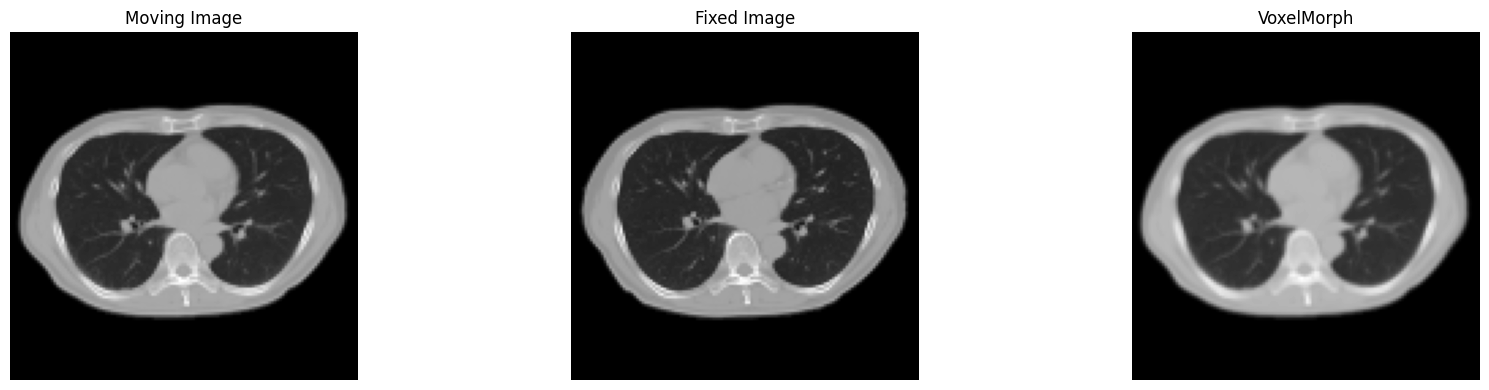


=== 📂 ペア: pair11 の評価結果 (slices 0..63) ===
| モデル名   |   Dice |   Jaccard |   SSIM |   FSIM |     RMSE |    NCC |
|------------|--------|-----------|--------|--------|----------|--------|
| VoxelMorph | 0.9308 |    0.8706 | 0.9551 | 0.8833 | 373.6953 | 0.9427 |
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])


KeyboardInterrupt: 

In [7]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
from skimage.metrics import structural_similarity as ssim
from tabulate import tabulate
from piq import fsim

# ======================
# 定数（ここで評価したいスライス範囲を指定）
# ======================
CT_MIN, CT_MAX = -1200.0, 3146.98
SLICE_SIZE = (64, 128, 128)
SLICE_IDX_VIEW = 32    # デフォルト表示スライス（範囲指定がある場合は中央スライスが使われる）
SLICE_IDX_FSIM = 28

# 評価したいスライス範囲を指定（例: 20〜40）
# None にすると全ボリュームで評価します
SLICE_START = None
SLICE_END = None

# ======================
# 評価関数（変更なし）
# ======================
def compute_rmse(vol1, vol2):
    return np.sqrt(np.mean((vol1 - vol2) ** 2))

import torch
import torch.nn.functional as F
import numpy as np

def _gaussian_kernel_3d(window_size=7, sigma=1.5, device='cpu', dtype=torch.float32):
    coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
    g1 = torch.exp(-(coords**2) / (2 * sigma**2))
    g1 = g1 / g1.sum()
    g3 = g1[:, None, None] * g1[None, :, None] * g1[None, None, :]
    return g3.unsqueeze(0).unsqueeze(0)  # shape (1,1,D,H,W)

def _ssim_components_3d(x, y, window, K1=0.01, K2=0.03, eps=1e-12):
    """
    Compute luminance, contrast, structure maps for 3D volumes.
    x,y : tensors with shape (N,1,D,H,W)
    window : gaussian kernel shape (1,1,d,h,w)
    returns (l_map, cs_map) where cs_map = contrast * structure
    """
    pad = tuple([s//2 for s in window.shape[-3:]])
    mu_x = F.conv3d(x, window, padding=pad)
    mu_y = F.conv3d(y, window, padding=pad)

    mu_x_sq = mu_x * mu_x
    mu_y_sq = mu_y * mu_y
    mu_xy = mu_x * mu_y

    sigma_x_sq = F.conv3d(x * x, window, padding=pad) - mu_x_sq
    sigma_y_sq = F.conv3d(y * y, window, padding=pad) - mu_y_sq
    sigma_xy = F.conv3d(x * y, window, padding=pad) - mu_xy

    sigma_x_sq = torch.clamp(sigma_x_sq, min=0.0)
    sigma_y_sq = torch.clamp(sigma_y_sq, min=0.0)

    sigma_x = torch.sqrt(sigma_x_sq + eps)
    sigma_y = torch.sqrt(sigma_y_sq + eps)

    # Estimate L (data range) per-sample for numeric C's
    N = x.shape[0]
    max_x = x.view(N, -1).max(dim=1)[0].view(N,1,1,1,1)
    min_x = x.view(N, -1).min(dim=1)[0].view(N,1,1,1,1)
    max_y = y.view(N, -1).max(dim=1)[0].view(N,1,1,1,1)
    min_y = y.view(N, -1).min(dim=1)[0].view(N,1,1,1,1)
    L = torch.max(max_x - min_x, max_y - min_y)
    L = torch.clamp(L, min=eps)

    C1 = (K1 * L) ** 2
    C2 = (K2 * L) ** 2
    C3 = C2 / 2.0

    l_map = (2.0 * mu_xy + C1) / (mu_x_sq + mu_y_sq + C1 + eps)
    contrast = (2.0 * sigma_x * sigma_y + C2) / (sigma_x_sq + sigma_y_sq + C2 + eps)
    structure = (sigma_xy + C3) / (sigma_x * sigma_y + C3 + eps)

    cs_map = contrast * structure
    return l_map.clamp(min=eps), cs_map.clamp(min=eps)

def ms_ssim_3d(vol1, vol2,
               window_size=7, sigma=1.5,
               levels=5,
               weights=None,
               K1=0.01, K2=0.03, eps=1e-12,
               device=None):
    """
    Multi-scale SSIM for 3D volumes.
    vol1, vol2 : torch tensor or numpy array, shapes supported:
        (N,C,D,H,W), (C,D,H,W), (D,H,W)
    levels : number of scales (default 5)
    weights : list/tuple of length `levels` of weights summing to 1 (if None, use default MS-SSIM weights)
    returns: python float (mean MS-SSIM over batch)
    """
    # default MS-SSIM weights from the original paper (for 5 scales)
    if weights is None:
        # note: these are standard for 5-scale MS-SSIM
        weights = [0.0448, 0.2856, 0.3001, 0.2363, 0.1333]
    if len(weights) != levels:
        raise ValueError("len(weights) must equal levels")

    # convert numpy -> torch
    is_numpy = isinstance(vol1, np.ndarray) or isinstance(vol2, np.ndarray)
    if is_numpy:
        vol1 = torch.from_numpy(np.array(vol1))
        vol2 = torch.from_numpy(np.array(vol2))

    if not torch.is_tensor(vol1) or not torch.is_tensor(vol2):
        raise TypeError("vol1/vol2 must be numpy or torch tensor")

    # determine device
    if device is None:
        device = vol1.device if hasattr(vol1, 'device') else torch.device('cpu')
    device = torch.device(device)

    vol1 = vol1.to(device=device, dtype=torch.float32)
    vol2 = vol2.to(device=device, dtype=torch.float32)

    # normalize shapes to (N,C,D,H,W)
    def _ensure5d(x):
        if x.dim() == 5:
            return x
        if x.dim() == 4:
            return x.unsqueeze(0)
        if x.dim() == 3:
            return x.unsqueeze(0).unsqueeze(0)
        raise ValueError("Unsupported tensor shape: {}".format(x.shape))

    x = _ensure5d(vol1)
    y = _ensure5d(vol2)

    # unify channels by mean (if needed)
    if x.shape[1] != y.shape[1] or x.shape[1] > 1:
        x = x.mean(dim=1, keepdim=True)
        y = y.mean(dim=1, keepdim=True)

    N, C, D, H, W = x.shape

    # create gaussian kernel once
    window = _gaussian_kernel_3d(window_size=window_size, sigma=sigma, device=device, dtype=x.dtype)

    mcs = []   # mean contrast-structure per scale
    for lvl in range(levels):
        # if volume becomes too small to downsample, stop early
        if min(D, H, W) < 2:
            # compute final scale components and break
            l_map, cs_map = _ssim_components_3d(x, y, window, K1=K1, K2=K2, eps=eps)
            mcs.append(cs_map.view(N, -1).mean(dim=1))  # shape (N,)
            break

        l_map, cs_map = _ssim_components_3d(x, y, window, K1=K1, K2=K2, eps=eps)
        # mean over spatial dims gives per-sample scalar
        mcs.append(cs_map.view(N, -1).mean(dim=1))

        # downsample for next scale using average pooling (anti-aliasing)
        # kernel_size=2, stride=2
        x = F.avg_pool3d(x, kernel_size=2, stride=2, padding=0)
        y = F.avg_pool3d(y, kernel_size=2, stride=2, padding=0)
        N, C, D, H, W = x.shape

    # last scale luminance
    l_map, cs_map = _ssim_components_3d(x, y, window, K1=K1, K2=K2, eps=eps)
    l_mean = l_map.view(N, -1).mean(dim=1)  # per-sample

    # If we generated fewer mcs than requested levels (due to small volume), adjust weights
    actual_levels = len(mcs)
    if actual_levels < levels:
        # use last `actual_levels` weights and normalized
        w = torch.tensor(weights[:actual_levels], device=device, dtype=x.dtype)
        w = w / w.sum()
        used_weights = w
        # last weight for luminance is taken as original last weight mapped proportionally
        lum_weight = weights[min(actual_levels-1, len(weights)-1)]
    else:
        used_weights = torch.tensor(weights[:levels-1], device=device, dtype=x.dtype)  # weights for cs scales except last
        lum_weight = weights[levels-1]

    # compute MS-SSIM per sample:
    # product over scales of (mcs_i ^ weight_i)  and multiply by (l_mean ^ lum_weight)
    # convert list of tensors to shape (actual_levels, N)
    mcs_t = torch.stack(mcs[:actual_levels], dim=0)  # shape (actual_levels, N)
    # choose weights for these mcs: if actual_levels == levels -> first (levels-1) are cs weights, last is cs too
    if actual_levels == levels:
        cs_weights = torch.tensor(weights[:levels-1], device=device, dtype=x.dtype)
        # there are levels-1 cs entries and last is l_mean
        # mcs_t has length levels-1 (we appended cs for each scale before downsample), plus we still have final cs? 
        # Here we've appended cs at each level before downsampling, and computed final l_map after last downsample.
        # For typical MS-SSIM: use cs means from all levels and l only from last one.
        # So mcs_t currently includes cs for all levels (length == levels). In our loop we appended cs each iteration, and after final downsample we appended final cs too.
        # To match standard weights: use weights[:levels] for cs and lum_weight for l.
        cs_weights = torch.tensor(weights[:actual_levels], device=device, dtype=x.dtype)
    else:
        # when smaller, distribute weights proportionally — use used_weights for cs
        cs_weights = used_weights

    # Ensure cs_weights length matches mcs_t length
    if cs_weights.numel() != mcs_t.shape[0]:
        # simple fallback: evenly distribute
        cs_weights = torch.ones(mcs_t.shape[0], device=device, dtype=x.dtype) / float(mcs_t.shape[0])

    # raise mcs to weights and multiply (per-sample)
    # mcs_t ** cs_weights[:,None] -> shape (L, N)
    # product over rows -> (N,)
    ms_prod = torch.prod(mcs_t.pow(cs_weights.view(-1,1)), dim=0)
    ms_l = l_mean.pow(float(lum_weight))
    ms_per_sample = ms_prod * ms_l

    # return mean over batch as python float
    return float(ms_per_sample.mean().item())

def compute_fsim(vol1, vol2, device):
    """中央スライスでFSIMを評価（ただしこのスクリプトでは通常中央は範囲中央値に合わせる）"""
    v1 = vol1
    v2 = vol2
    # v1, v2 expected shape (C, D, H, W) or (D, H, W). Normalize access:
    if np.asarray(v1).ndim == 3:
        D = v1.shape[0]
    else:
        D = np.asarray(v1).shape[1]
    idx = min(SLICE_IDX_FSIM, max(0, D - 1))
    # Build tensors robustly for either shape
    if np.asarray(v1).ndim == 3:
        fixed_tensor = torch.tensor(v1[idx]).unsqueeze(0).unsqueeze(0).float().to(device)
        pred_tensor = torch.tensor(v2[idx]).unsqueeze(0).unsqueeze(0).float().to(device)
    else:
        fixed_tensor = torch.tensor(v1[:, idx, :, :]).unsqueeze(1).float().to(device)
        pred_tensor = torch.tensor(v2[:, idx, :, :]).unsqueeze(1).float().to(device)
        fixed_tensor = fixed_tensor[0].unsqueeze(0)
        pred_tensor = pred_tensor[0].unsqueeze(0)
    try:
        return fsim(pred_tensor, fixed_tensor, data_range=1.0, chromatic=False).item()
    except Exception:
        return float('nan')

def compute_ncc(vol1, vol2):
    v1 = vol1.flatten().astype(np.float32)
    v2 = vol2.flatten().astype(np.float32)
    v1_mean = v1.mean()
    v2_mean = v2.mean()
    numerator = np.sum((v1 - v1_mean) * (v2 - v2_mean))
    denominator = np.sqrt(np.sum((v1 - v1_mean) ** 2) * np.sum((v2 - v2_mean) ** 2) + 1e-8)
    return numerator / denominator

def compute_metrics(fixed, transformed, device, model_name):
    """Dice, Jaccard, SSIM, FSIM, RMSE, NCC をまとめて計算（入力は部分ボリュームでも可）"""
    fixed_bin = (fixed > 0.144).astype(int)
    transformed_bin = (transformed > 0.144).astype(int)

    dice = 2.0 * np.logical_and(fixed_bin, transformed_bin).sum() / (fixed_bin.sum() + transformed_bin.sum() + 1e-8)
    jaccard = np.logical_and(fixed_bin, transformed_bin).sum() / (np.logical_or(fixed_bin, transformed_bin).sum() + 1e-8)
#     ssim_val = compute_ssim_3d(fixed, transformed)
    ssim_val = ms_ssim_3d(fixed, transformed, levels=5, device='cpu')
    fsim_val = compute_fsim(fixed, transformed, device)
    ncc_val = compute_ncc(fixed, transformed)

    # RMSE用にCT値を復元
    pred_denorm = transformed * (CT_MAX - CT_MIN) + CT_MIN
    true_denorm = fixed * (CT_MAX - CT_MIN) + CT_MIN
    rmse_val = compute_rmse(true_denorm, pred_denorm)

    return [model_name, dice, jaccard, ssim_val, fsim_val, rmse_val, ncc_val]

# ======================
# 表示ユーティリティ（どちらの形でも扱えるようにする）
# ======================
def _ensure_channel_first_np(vol):
    v = np.asarray(vol)
    if v.ndim == 3:
        return v[np.newaxis, ...]
    if v.ndim == 4:
        return v
    raise ValueError(f"Unexpected array shape {v.shape} in _ensure_channel_first_np")

def show_images(moving, fixed, transformed_images, slice_idx=None):
    """
    display grid; slice_idx: if None, use central slice of available depth
    """
    mv = _ensure_channel_first_np(moving)
    fx = _ensure_channel_first_np(fixed)
    # choose slice idx
    if slice_idx is None:
        slice_idx = min(mv.shape[1], fx.shape[1]) // 2
    slice_idx = max(0, min(slice_idx, min(mv.shape[1], fx.shape[1]) - 1))

    imgs = []
    imgs.append((mv[0, slice_idx], "Moving Image"))
    imgs.append((fx[0, slice_idx], "Fixed Image"))
    for name, img in transformed_images.items():
        v = _ensure_channel_first_np(img)
        sidx = min(slice_idx, v.shape[1] - 1)
        imgs.append((v[0, sidx], name))

    n = len(imgs)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (img2d, title) in zip(axes, imgs):
        ax.imshow(img2d, cmap="gray")
        ax.set_title(title)
        ax.axis('off')
    for ax in axes[len(imgs):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# ======================
# ペア処理（スライス範囲で評価）
# ======================
def process_pair(pair_folder, models, device, all_results, all_vec_stats, slice_start=SLICE_START, slice_end=SLICE_END):
    npz_files = sorted(glob.glob(os.path.join(pair_folder, '*.npz')))
    if len(npz_files) != 2:
        print(f"{pair_folder} に .npz ファイルが2つ存在しません")
        return

    moving = np.load(npz_files[1])['Train'][np.newaxis, ..., np.newaxis]
    fixed = np.load(npz_files[0])['Train'][np.newaxis, ..., np.newaxis]

    moving_t = torch.tensor(moving).permute(0, 4, 1, 2, 3).float()
    fixed_t = torch.tensor(fixed).permute(0, 4, 1, 2, 3).float()

    moving_t = torch.nn.functional.interpolate(moving_t, size=SLICE_SIZE, mode='trilinear', align_corners=False).to(device)
    fixed_t = torch.nn.functional.interpolate(fixed_t, size=SLICE_SIZE, mode='trilinear', align_corners=False).to(device)

    results = []
    transformed_images = {}

    with torch.no_grad():
        # まず各モデルの出力を得ておく（評価は部分ボリュームで行う）
        transformed_dict = {}
        vec_dict = {}
        for name, model in models.items():
            model.eval()
            try:
                out = model(moving_t, fixed_t)
            except TypeError:
                catimage = torch.cat([moving_t, fixed_t], dim=1)
                out = model(catimage)

            if isinstance(out, (tuple, list)):
                transformed = out[0]
                vec = out[1] if len(out) > 1 else None
            else:
                transformed = out
                vec = None

            if vec is not None and "HH" not in name:
                try:
                    all_vec_stats[name].append((vec.max().item(), vec.min().item()))
                except Exception:
                    pass

            transformed_np = transformed[0].cpu().numpy()
            if transformed_np.ndim == 4 and transformed_np.shape[0] == 1:
                transformed_np = transformed_np[0]
            transformed_dict[name] = transformed_np

        # 固定・moving を numpy に（空間形状）
        fixed_np = fixed_t[0].cpu().numpy()
        if fixed_np.ndim == 4 and fixed_np.shape[0] == 1:
            fixed_np = fixed_np[0]
        moving_np = moving_t[0].cpu().numpy()
        if moving_np.ndim == 4 and moving_np.shape[0] == 1:
            moving_np = moving_np[0]

        # decide slice range (clip to valid depth)
        D = fixed_np.shape[0]
        if slice_start is None:
            s0 = 0
        else:
            s0 = max(0, int(slice_start))
        if slice_end is None:
            s1 = D - 1
        else:
            s1 = min(D - 1, int(slice_end))
        if s1 < s0:
            s0, s1 = s1, s0  # swap if reversed

        # subvolume extraction (inclusive s0..s1)
        fixed_sub = fixed_np[s0:s1+1]
        moving_sub = moving_np[s0:s1+1]

        # 評価（各モデル）: 部分ボリュームで compute_metrics を呼ぶ
        for name, trans_np in transformed_dict.items():
            # guard if model's depth differs: extract corresponding slices (clamp)
            if trans_np.shape[0] >= (s1 - s0 + 1):
                # try to align same start: if depths equal, take same start; otherwise clamp mapping
                # simplest: take slices s0..s1 from model output if available, else take central window
                try:
                    trans_sub = trans_np[s0:s1+1]
                except Exception:
                    # fallback: if trans_np has different ordering, take center crop of same length
                    L = s1 - s0 + 1
                    if trans_np.shape[0] >= L:
                        start_idx = (trans_np.shape[0] - L) // 2
                        trans_sub = trans_np[start_idx:start_idx+L]
                    else:
                        # pad/truncate: use available full trans_np
                        trans_sub = trans_np
            else:
                # model output shorter than requested window: use available and pad by repeating last slice
                L = s1 - s0 + 1
                reps = []
                for i in range(L):
                    idx = min(i, trans_np.shape[0]-1)
                    reps.append(trans_np[idx])
                trans_sub = np.stack(reps, axis=0)

            # For compute_metrics we need channel-first (C,D,H,W) or (D,H,W) works if consistent.
            # The compute_metrics expects e.g. (C,D,H,W) with channel as first dim; original code used fixed[0,...]
            # So convert to shape (1,D,H,W)
            fixed_input = fixed_sub[np.newaxis, ...]
            trans_input = trans_sub[np.newaxis, ...]

            metrics = compute_metrics(fixed_input, trans_input, device, name)
            results.append(metrics)
            all_results[name].append(metrics[1:])  # exclude model name for storing

            # for display, keep full transformed (not sub) so user can inspect middle slice later
            transformed_images[name] = trans_np

    # show images using middle slice of the chosen window
    mid_slice = s0 + (s1 - s0) // 2
    show_images(moving_t[0].cpu().numpy(), fixed_t[0].cpu().numpy(), transformed_images, slice_idx=32)

    print(f"\n=== 📂 ペア: {os.path.basename(pair_folder)} の評価結果 (slices {s0}..{s1}) ===")
    print(tabulate(results, headers=["モデル名", "Dice", "Jaccard", "SSIM", "FSIM", "RMSE", "NCC"], floatfmt=".4f", tablefmt="github"))

# ======================
# メイン処理（呼び出しは同じ）
# ======================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    output_dir = r"D:\Saito\Data\TestData"

    # モデルの辞書（あなたの環境で定義済みのモデルを参照）
    models = {
        "VoxelMorph": model_VoxelMorph,
        # "VoxelMorph+CL": model_VoxelMorph_CL,
        # "VoxelMorph+WE": model_VoxelMorph_WE,
        # "VoxelMorph+CL+WE": model_VoxelMorph_CL_WE,  # ←全角＋を半角+に
    }

    all_results = {name: [] for name in models}
    all_vec_stats = {name: [] for name in models if "HH" not in name}

    pair_folders = [os.path.join(output_dir, p) for p in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, p))]
    print(f"🔍 総ペア数: {len(pair_folders)}")

    for pair_folder in pair_folders:
        process_pair(pair_folder, models, device, all_results, all_vec_stats)

    # 平均結果
    avg_results = []
    for name, values in all_results.items():
        if values:
            values = np.array(values)
            avg = values.mean(axis=0)
            avg_results.append([name, *avg])

    print("\n=== 📈 全ペアにおける変形ベクトルの統計 ===")
    for name, stats in all_vec_stats.items():
        if stats:
            max_vals, min_vals = zip(*stats)
            print(f"{name}: Max 平均={np.mean(max_vals):.4f}±{np.std(max_vals):.4f}, "
                  f"Min 平均={np.mean(min_vals):.4f}±{np.std(min_vals):.4f}")

    print("\n=== 📊 全ペアの平均結果 ===")
    print(tabulate(avg_results, headers=["モデル名", "平均Dice", "平均Jaccard", "平均SSIM", "平均FSIM", "平均RMSE", "平均NCC"], floatfmt=".4f", tablefmt="github"))

if __name__ == "__main__":
    main()
